# LOD Variance Analysis

Decomposing Length-of-Day variability into spectral components and comparing with
atmospheric (AAM) and oceanic (OAM) angular momentum forcing.

**Key signals in LOD:**
- Decadal variations (~10-30 yr) — core-mantle coupling
- Annual (~365.25 d) — atmospheric/oceanic seasonal forcing
- Semi-annual (~182.6 d) — atmospheric
- Tidal (fortnightly ~13.66 d, monthly ~27.55 d)

**Key signals in polar motion (wobble):**
- Chandler wobble (~433 d) — free wobble of Earth, damped & excited
- Annual wobble (~365.25 d) — seasonal mass redistribution

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

DATA_DIR = Path('../data')

## 1. Load EOP C04 — daily LOD + polar motion

In [17]:
# Load raw daily EOP C04 (no resampling — we want full resolution)
eop = pd.read_csv(
    DATA_DIR / 'EOP_14_C04_IAU2000A_one_file_1962-now.txt',
    delim_whitespace=True,
    skiprows=14,
    names=['Year','Month','Day','MJD',
           'x','y','UT1_UTC','LOD',
           'dX','dY','x_Err','y_Err',
           'UT1_UTC_Err','LOD_Err','dX_Err','dY_Err']
)
eop['date'] = pd.to_datetime(eop[['Year','Month','Day']])
eop.set_index('date', inplace=True)

# LOD is excess LOD in seconds; convert to ms
eop['LOD_ms'] = eop['LOD'] * 1000

# Polar motion in arcseconds (already in the file)
print(f"EOP date range: {eop.index[0].date()} to {eop.index[-1].date()}")
print(f"Records: {len(eop):,}")
eop[['LOD_ms','x','y']].describe()

EOP date range: 1962-01-01 to 2026-01-05
Records: 23,381


/var/folders/l_/gygrhglj1vvc7rfw922_nb440000gn/T/ipykernel_66298/1871831226.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  eop = pd.read_csv(


,LOD_ms,x,y
count,23381.000000,23381.000000,23381.000000
mean,1.501514,0.050882,0.301886
std,1.074587,0.128735,0.128826
min,-1.633400,-0.306190,-0.022920
25%,0.699700,-0.038690,0.207893
50%,1.494300,0.057244,0.307967
75%,2.349000,0.150899,0.401043
max,4.355000,0.324420,0.596877


## 2. LOD time series overview

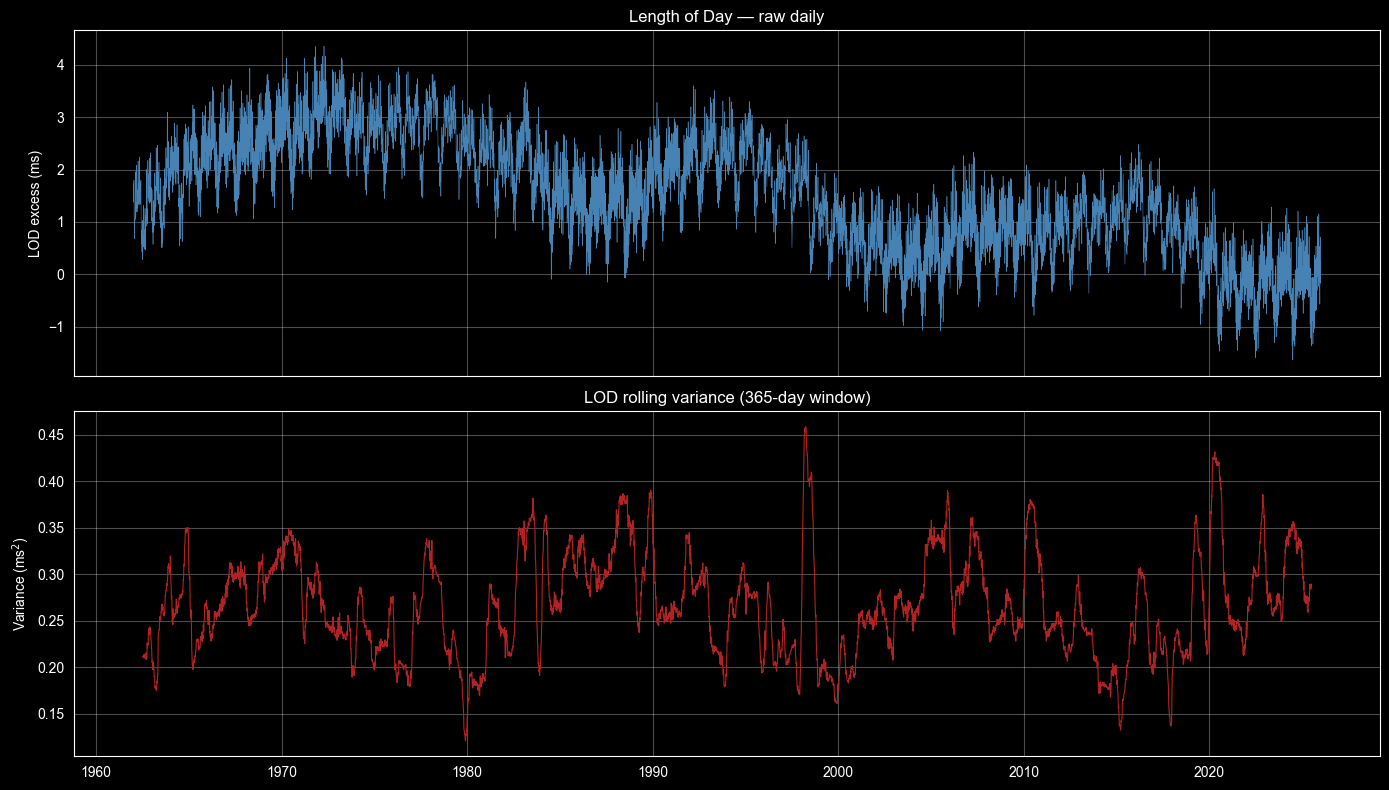

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(eop.index, eop['LOD_ms'], lw=0.4, color='steelblue')
axes[0].set_ylabel('LOD excess (ms)')
axes[0].set_title('Length of Day — raw daily')

# Rolling variance (1-year window)
rolling_var = eop['LOD_ms'].rolling(365, center=True).var()
axes[1].plot(eop.index, rolling_var, lw=0.8, color='firebrick')
axes[1].set_ylabel('Variance (ms$^2$)')
axes[1].set_title('LOD rolling variance (365-day window)')

plt.tight_layout()
plt.show()

## 3. Detrend LOD — remove decadal signal

The decadal variation (core-mantle coupling) dominates the total variance.
Remove it with a low-pass filter to focus on sub-decadal forcing.

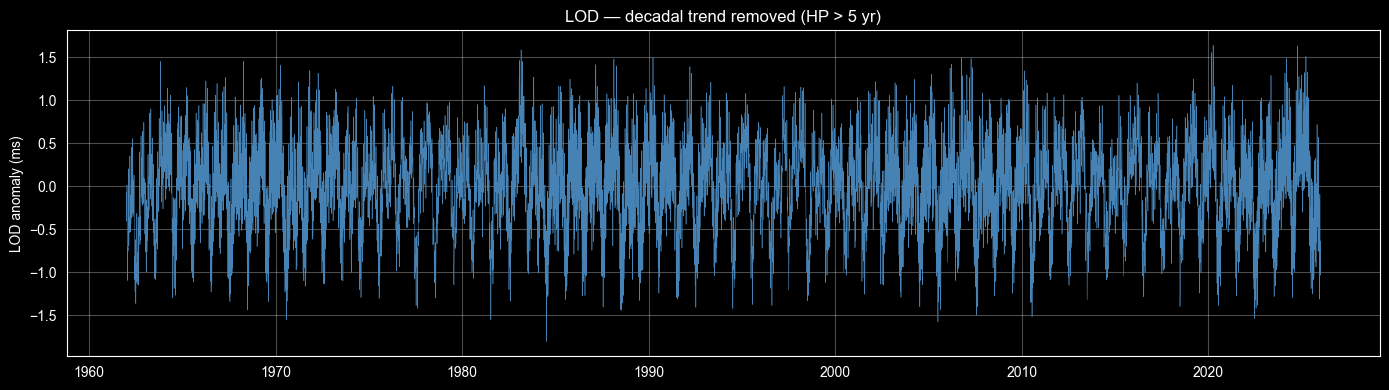

Detrended LOD std: 0.5236 ms
Detrended LOD variance: 0.274178 ms²


In [19]:
# Butterworth high-pass: remove periods > 5 years
fs = 1.0  # 1 sample/day
f_cutoff = 1.0 / (5 * 365.25)  # 5-year cutoff
sos_hp = signal.butter(4, f_cutoff, btype='high', fs=fs, output='sos')

# Drop NaNs for filtering
lod_clean = eop['LOD_ms'].dropna()
lod_detrended = pd.Series(
    signal.sosfiltfilt(sos_hp, lod_clean.values),
    index=lod_clean.index,
    name='LOD_detrended_ms'
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(lod_detrended.index, lod_detrended, lw=0.4, color='steelblue')
ax.set_ylabel('LOD anomaly (ms)')
ax.set_title('LOD — decadal trend removed (HP > 5 yr)')
plt.tight_layout()
plt.show()

print(f"Detrended LOD std: {lod_detrended.std():.4f} ms")
print(f"Detrended LOD variance: {lod_detrended.var():.6f} ms²")

## 4. Spectral analysis of LOD

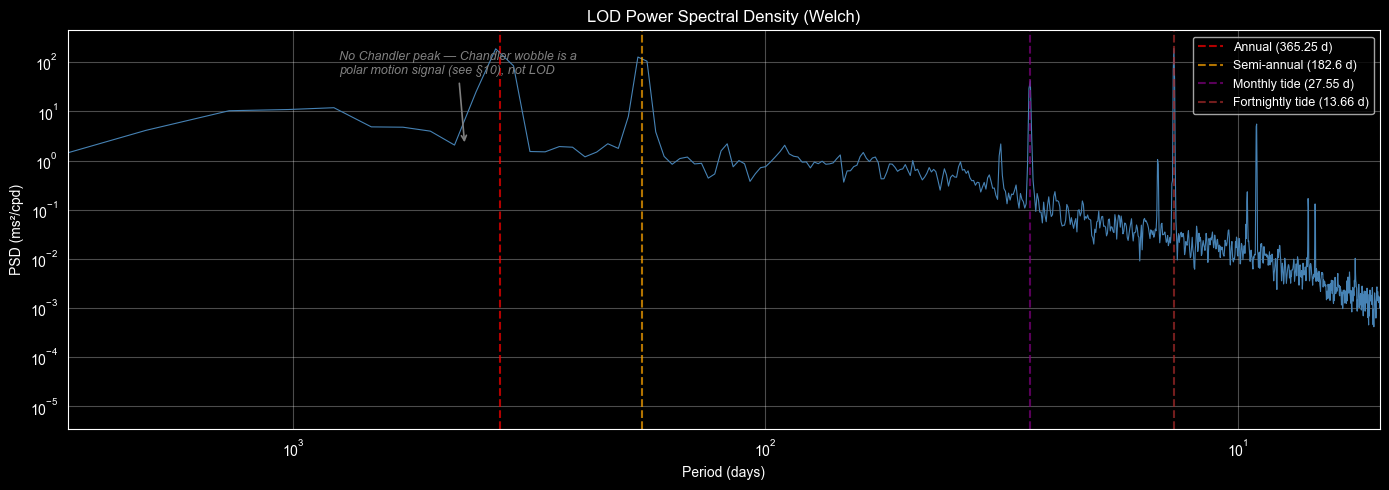

In [20]:
# Welch PSD of detrended LOD
nperseg = 4096  # ~11 years per segment
freqs, psd = signal.welch(lod_detrended.values, fs=fs, nperseg=nperseg, noverlap=nperseg//2)

periods_days = 1.0 / freqs[1:]  # skip DC
psd_plot = psd[1:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.loglog(periods_days, psd_plot, lw=0.8, color='steelblue')

# Mark key LOD periods (axial signals only)
key_periods = {
    'Annual (365.25 d)': 365.25,
    'Semi-annual (182.6 d)': 182.6,
    'Monthly tide (27.55 d)': 27.55,
    'Fortnightly tide (13.66 d)': 13.66,
}
colors = ['red', 'orange', 'purple', 'brown']
for (label, p), c in zip(key_periods.items(), colors):
    ax.axvline(p, ls='--', alpha=0.7, color=c, label=label)

ax.set_xlabel('Period (days)')
ax.set_ylabel('PSD (ms²/cpd)')
ax.set_title('LOD Power Spectral Density (Welch)')
ax.set_xlim(5, 3000)
ax.legend(fontsize=9)
ax.invert_xaxis()
ax.annotate('No Chandler peak — Chandler wobble is a\npolar motion signal (see §10), not LOD',
            xy=(433, psd_plot[np.argmin(np.abs(periods_days - 433))]),
            xytext=(800, psd_plot.max() * 0.3),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
            fontsize=9, color='gray', style='italic')
plt.tight_layout()
plt.show()

## 5. Bandpass filtering — extract annual + semi-annual + tidal bands

In [21]:
def bandpass(data, period_lo, period_hi, fs=1.0, order=4):
    """Bandpass filter between period_hi and period_lo days (period_hi < period_lo)."""
    f_lo = 1.0 / period_lo   # lower freq
    f_hi = 1.0 / period_hi   # upper freq
    sos = signal.butter(order, [f_lo, f_hi], btype='band', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, data)

lod_vals = lod_detrended.values

# Annual band: 300-430 days (captures annual, avoids Chandler)
lod_annual = bandpass(lod_vals, 430, 300)

# Semi-annual band: 150-220 days
lod_semiannual = bandpass(lod_vals, 220, 150)

# Tidal band: 10-35 days (fortnightly + monthly)
lod_tidal = bandpass(lod_vals, 35, 10)

# Intraseasonal band: 35-150 days (MJO, etc.)
lod_intraseasonal = bandpass(lod_vals, 150, 35)

# Compute variances
total_var = np.var(lod_vals)
bands = {
    'Annual (300-430 d)': np.var(lod_annual),
    'Semi-annual (150-220 d)': np.var(lod_semiannual),
    'Intraseasonal (35-150 d)': np.var(lod_intraseasonal),
    'Tidal (10-35 d)': np.var(lod_tidal),
}
residual_var = total_var - sum(bands.values())
bands['Residual'] = residual_var

print(f"Total detrended LOD variance: {total_var:.6f} ms²\n")
print(f"{'Band':<30} {'Variance (ms²)':>15} {'% of total':>12}")
print('-' * 60)
for name, v in bands.items():
    print(f"{name:<30} {v:>15.6f} {100*v/total_var:>11.1f}%")

Total detrended LOD variance: 0.274166 ms²

Band                            Variance (ms²)   % of total
------------------------------------------------------------
Annual (300-430 d)                    0.069373        25.3%
Semi-annual (150-220 d)               0.060405        22.0%
Intraseasonal (35-150 d)              0.015979         5.8%
Tidal (10-35 d)                       0.098294        35.9%
Residual                              0.030115        11.0%


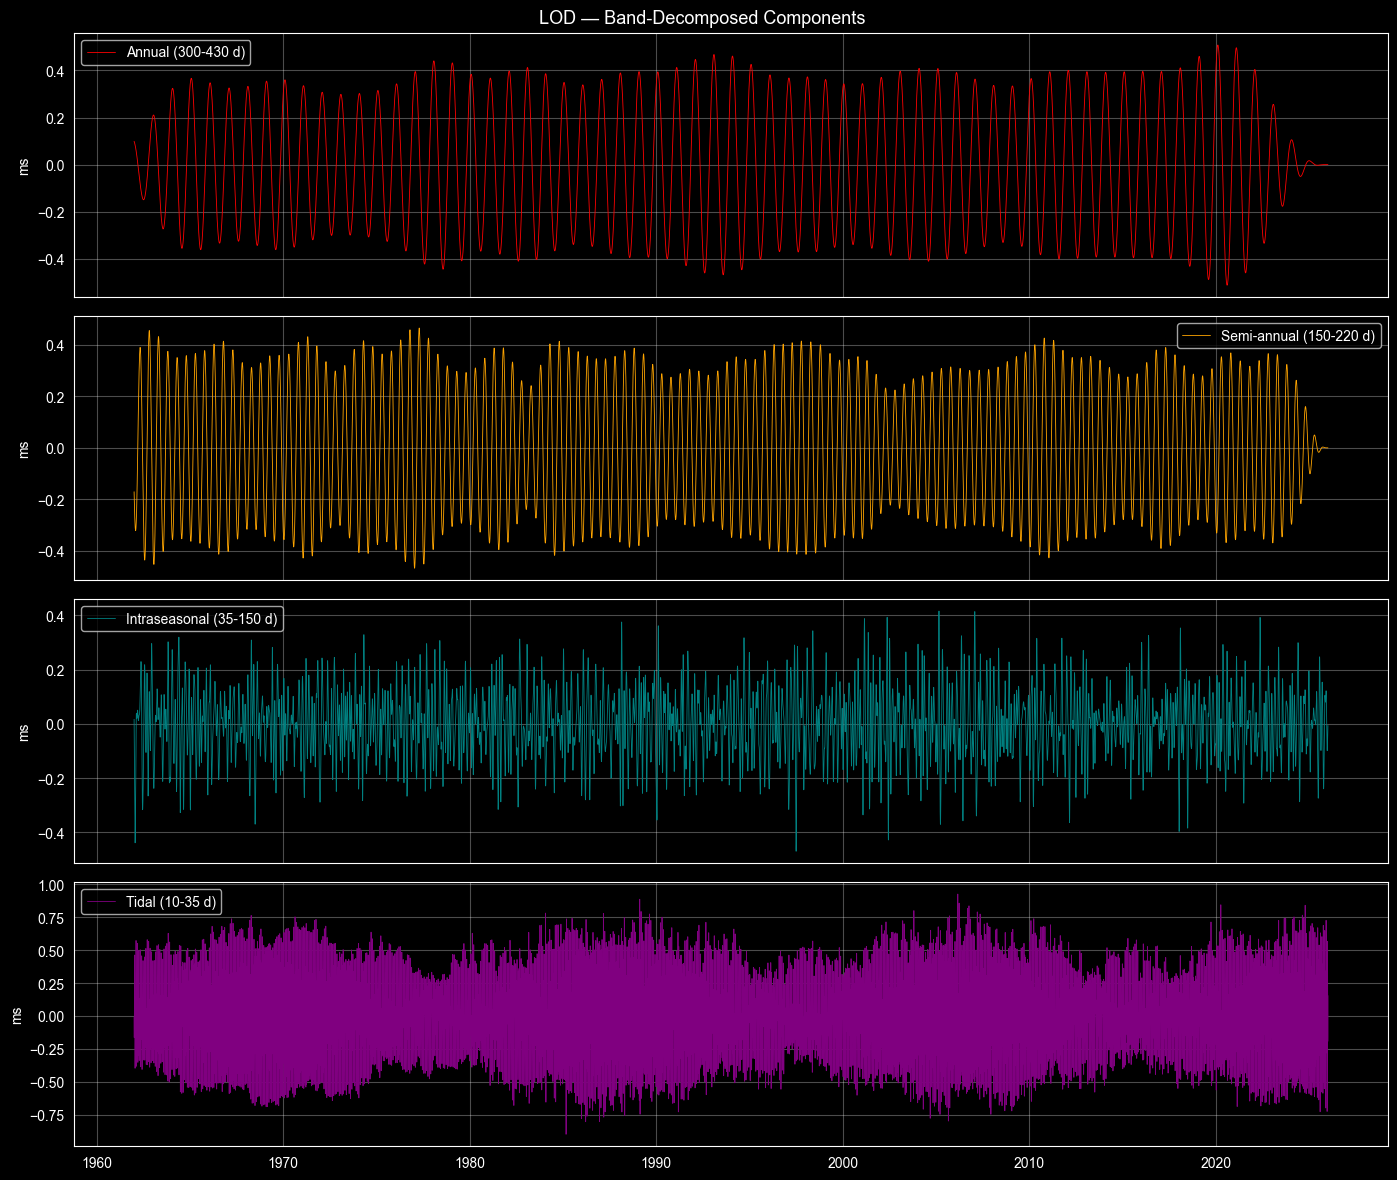

In [22]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(lod_detrended.index, lod_annual, lw=0.6, color='red', label='Annual (300-430 d)')
axes[0].set_ylabel('ms')
axes[0].legend()

axes[1].plot(lod_detrended.index, lod_semiannual, lw=0.6, color='orange', label='Semi-annual (150-220 d)')
axes[1].set_ylabel('ms')
axes[1].legend()

axes[2].plot(lod_detrended.index, lod_intraseasonal, lw=0.6, color='teal', label='Intraseasonal (35-150 d)')
axes[2].set_ylabel('ms')
axes[2].legend()

axes[3].plot(lod_detrended.index, lod_tidal, lw=0.6, color='purple', label='Tidal (10-35 d)')
axes[3].set_ylabel('ms')
axes[3].legend()

fig.suptitle('LOD — Band-Decomposed Components', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Rolling variance by band — temporal evolution

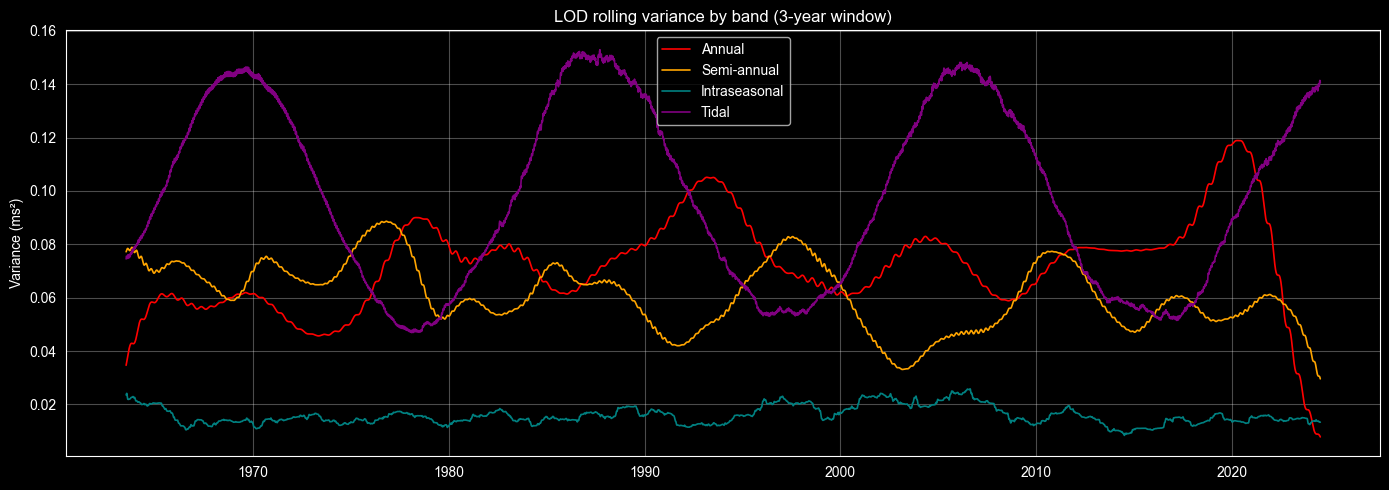

In [23]:
window = 3 * 365  # 3-year rolling window

rv_annual = pd.Series(lod_annual, index=lod_detrended.index).rolling(window, center=True).var()
rv_semiannual = pd.Series(lod_semiannual, index=lod_detrended.index).rolling(window, center=True).var()
rv_intraseasonal = pd.Series(lod_intraseasonal, index=lod_detrended.index).rolling(window, center=True).var()
rv_tidal = pd.Series(lod_tidal, index=lod_detrended.index).rolling(window, center=True).var()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rv_annual.index, rv_annual, lw=1.2, color='red', label='Annual')
ax.plot(rv_semiannual.index, rv_semiannual, lw=1.2, color='orange', label='Semi-annual')
ax.plot(rv_intraseasonal.index, rv_intraseasonal, lw=1.2, color='teal', label='Intraseasonal')
ax.plot(rv_tidal.index, rv_tidal, lw=1.2, color='purple', label='Tidal')
ax.set_ylabel('Variance (ms²)')
ax.set_title('LOD rolling variance by band (3-year window)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. AAM axial forcing (X3) — comparison with LOD

In [24]:
# Load all AAM data at 3-hourly resolution, resample to daily
from ecdo_analysis.data_loaders import load_aam_data

aam_daily = load_aam_data(str(DATA_DIR), resample_freq='D')
print(f"AAM date range: {aam_daily.index[0].date()} to {aam_daily.index[-1].date()}")
print(f"Records: {len(aam_daily):,}")

# Align with LOD
common_idx = lod_detrended.index.intersection(aam_daily.index)
print(f"Overlapping days: {len(common_idx):,}")

AAM date range: 1976-01-01 to 2026-02-06
Records: 18,300
Overlapping days: 18,268


/var/folders/l_/gygrhglj1vvc7rfw922_nb440000gn/T/ipykernel_66298/3242604056.py:25: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/tedslusser/PycharmProjects/ecdo-analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


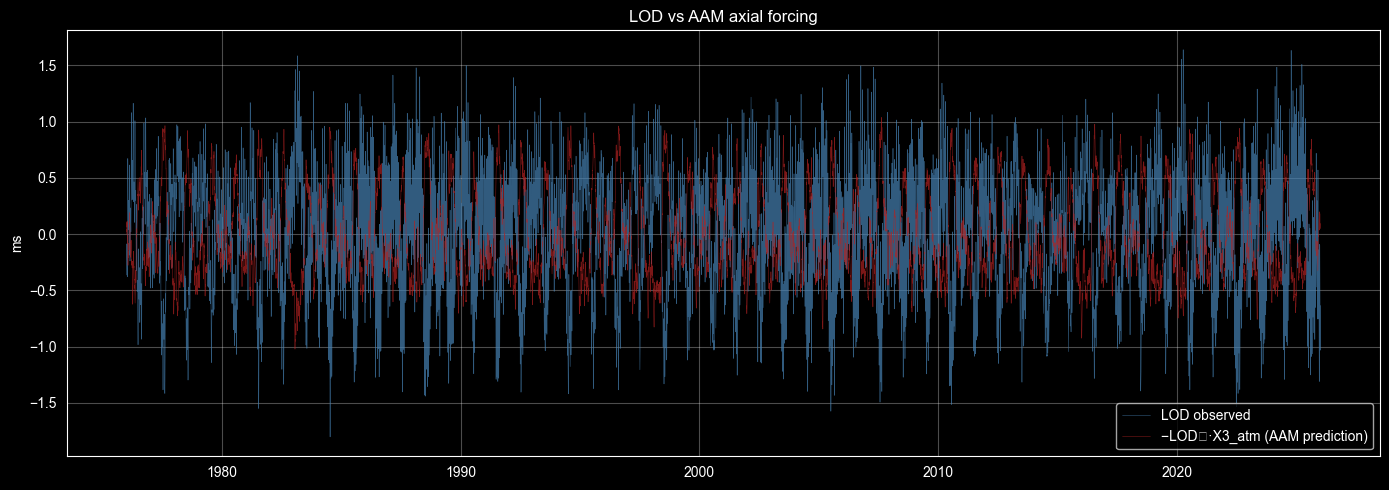

Correlation (LOD, -LOD0*X3): -0.7555


In [25]:
# X3_atm is the axial atmospheric excitation function
# LOD/LOD0 ≈ -X3 (to first order), where LOD0 = 86400 s
# So we expect anti-correlation between LOD anomaly and X3_atm

x3 = aam_daily.loc[common_idx, 'X3_atm']
lod_aligned = lod_detrended.loc[common_idx]

# Detrend X3 the same way
x3_clean = x3.dropna()
x3_detrended = pd.Series(
    signal.sosfiltfilt(sos_hp, x3_clean.values),
    index=x3_clean.index,
    name='X3_detrended'
)

# Scale X3 to LOD units: ΔLOD ≈ -LOD0 * X3 (LOD0=86400s, result in ms)
x3_as_lod = -86400.0 * 1000 * x3_detrended  # ms

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lod_aligned.index, lod_aligned, lw=0.4, alpha=0.7, color='steelblue', label='LOD observed')
ax.plot(x3_as_lod.index, x3_as_lod, lw=0.4, alpha=0.7, color='firebrick', label='−LOD₀·X3_atm (AAM prediction)')
ax.set_ylabel('ms')
ax.set_title('LOD vs AAM axial forcing')
ax.legend()
plt.tight_layout()
plt.show()

# Correlation
r = np.corrcoef(lod_aligned.loc[x3_as_lod.index], x3_as_lod)[0, 1]
print(f"Correlation (LOD, -LOD0*X3): {r:.4f}")

## 8. Variance budget — LOD vs AAM forcing

In [26]:
# Residual after removing AAM forcing = ocean + hydro + tidal + core-mantle
common = lod_aligned.index.intersection(x3_as_lod.index)
lod_c = lod_aligned.loc[common].values
aam_c = x3_as_lod.loc[common].values
residual = lod_c - aam_c

print(f"{'Component':<35} {'Variance (ms²)':>15} {'% of LOD var':>12}")
print('-' * 65)
print(f"{'LOD observed':<35} {np.var(lod_c):>15.6f} {100.0:>11.1f}%")
print(f"{'AAM forcing (-LOD0·X3)':<35} {np.var(aam_c):>15.6f} {100*np.var(aam_c)/np.var(lod_c):>11.1f}%")
print(f"{'Residual (LOD - AAM)':<35} {np.var(residual):>15.6f} {100*np.var(residual)/np.var(lod_c):>11.1f}%")
print(f"\nThe residual contains ocean, hydro, tidal, and other contributions.")

Component                            Variance (ms²) % of LOD var
-----------------------------------------------------------------
LOD observed                               0.273767       100.0%
AAM forcing (-LOD0·X3)                     0.142322        52.0%
Residual (LOD - AAM)                       0.714343       260.9%

The residual contains ocean, hydro, tidal, and other contributions.


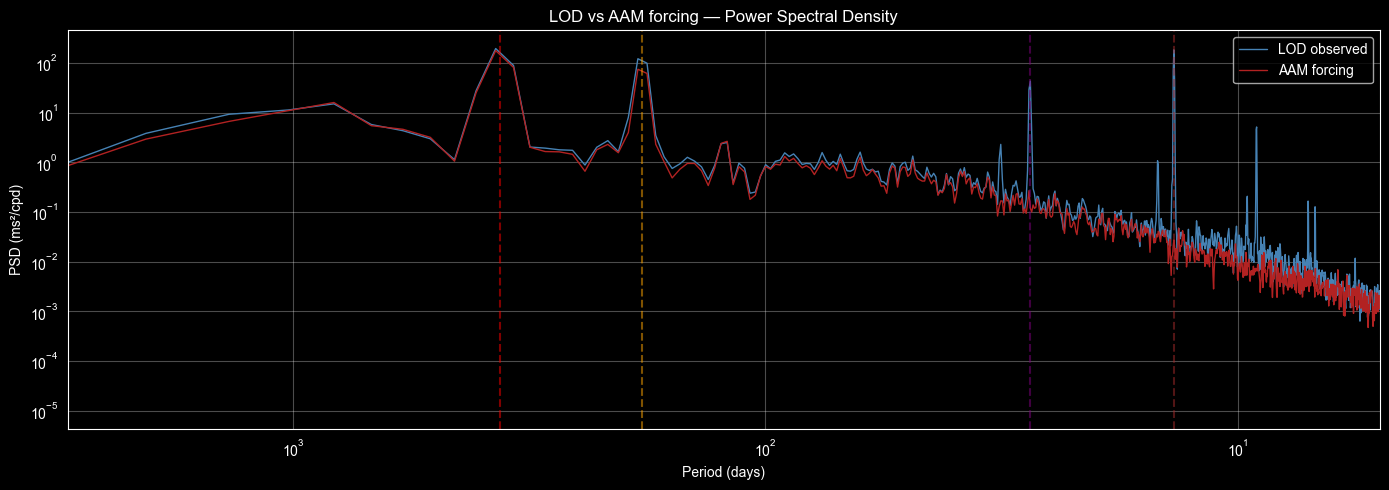

In [27]:
# Spectral comparison: LOD vs AAM forcing
common = lod_aligned.index.intersection(x3_as_lod.index)
lod_spec = lod_aligned.loc[common].values
aam_spec = x3_as_lod.loc[common].values

nperseg_c = min(4096, len(lod_spec) // 2)
f_lod, psd_lod = signal.welch(lod_spec, fs=1.0, nperseg=nperseg_c, noverlap=nperseg_c//2)
f_aam, psd_aam = signal.welch(aam_spec, fs=1.0, nperseg=nperseg_c, noverlap=nperseg_c//2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.loglog(1/f_lod[1:], psd_lod[1:], lw=1, color='steelblue', label='LOD observed')
ax.loglog(1/f_aam[1:], psd_aam[1:], lw=1, color='firebrick', label='AAM forcing')

lod_periods = {
    'Annual (365.25 d)': 365.25,
    'Semi-annual (182.6 d)': 182.6,
    'Monthly tide (27.55 d)': 27.55,
    'Fortnightly tide (13.66 d)': 13.66,
}
lod_colors = ['red', 'orange', 'purple', 'brown']
for (label, p), c in zip(lod_periods.items(), lod_colors):
    ax.axvline(p, ls='--', alpha=0.5, color=c)

ax.set_xlabel('Period (days)')
ax.set_ylabel('PSD (ms²/cpd)')
ax.set_title('LOD vs AAM forcing — Power Spectral Density')
ax.set_xlim(5, 3000)
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.show()

## 9. OAM axial forcing — if available

In [28]:
# Load OAM data (same format as AAM)
oam_files = sorted(DATA_DIR.glob('ESMGFZ_OAM_v1.0_03h_*.asc.csv'))

if oam_files:
    dfs = []
    for f in oam_files:
        df = pd.read_csv(f, sep=';')
        df['datetime'] = pd.to_datetime(
            df['Year'].astype(str) + '-' +
            df['Month'].astype(str).str.zfill(2) + '-' +
            df['Day'].astype(str).str.zfill(2) + ' ' +
            df['Time']
        )
        df.set_index('datetime', inplace=True)
        dfs.append(df)
    oam = pd.concat(dfs).sort_index()
    oam['X3_oam'] = oam['Mass_Z'] + oam['Motion_Z']
    oam_daily = oam[['X3_oam']].resample('D').mean()
    
    print(f"OAM date range: {oam_daily.index[0].date()} to {oam_daily.index[-1].date()}")
    print(f"Records: {len(oam_daily):,}")
    
    # Align all three
    idx3 = common_idx.intersection(oam_daily.index)
    x3_oam = oam_daily.loc[idx3, 'X3_oam'].dropna()
    x3_oam_det = pd.Series(
        signal.sosfiltfilt(sos_hp, x3_oam.values),
        index=x3_oam.index
    )
    oam_as_lod = -86400.0 * 1000 * x3_oam_det
    
    # Combined AAM + OAM
    idx_both = x3_as_lod.index.intersection(oam_as_lod.index)
    combined = x3_as_lod.loc[idx_both] + oam_as_lod.loc[idx_both]
    lod_b = lod_aligned.loc[idx_both]
    resid_aam_only = lod_b.values - x3_as_lod.loc[idx_both].values
    resid_both = lod_b.values - combined.values
    
    print(f"\n{'Component':<40} {'Variance (ms²)':>15} {'% of LOD':>10}")
    print('-' * 68)
    print(f"{'LOD observed':<40} {np.var(lod_b):>15.6f} {100:>9.1f}%")
    print(f"{'AAM forcing alone':<40} {np.var(x3_as_lod.loc[idx_both]):>15.6f} {100*np.var(x3_as_lod.loc[idx_both])/np.var(lod_b):>9.1f}%")
    print(f"{'AAM + OAM forcing':<40} {np.var(combined):>15.6f} {100*np.var(combined)/np.var(lod_b):>9.1f}%")
    print(f"{'Residual (LOD - AAM)':<40} {np.var(resid_aam_only):>15.6f} {100*np.var(resid_aam_only)/np.var(lod_b):>9.1f}%")
    print(f"{'Residual (LOD - AAM - OAM)':<40} {np.var(resid_both):>15.6f} {100*np.var(resid_both)/np.var(lod_b):>9.1f}%")
else:
    print('No OAM files found. Run download_data.sh to fetch them.')

OAM date range: 1976-01-01 to 2026-02-06
Records: 18,300

Component                                 Variance (ms²)   % of LOD
--------------------------------------------------------------------
LOD observed                                    0.273767     100.0%
AAM forcing alone                               0.142322      52.0%
AAM + OAM forcing                               0.137814      50.3%
Residual (LOD - AAM)                            0.714343     260.9%
Residual (LOD - AAM - OAM)                      0.705816     257.8%


## 10. Polar motion — Chandler & annual wobble

Complex polar motion $m = x - iy$ (geodetic convention).
Prograde Chandler wobble at ~433 days, annual wobble at ~365.25 days.

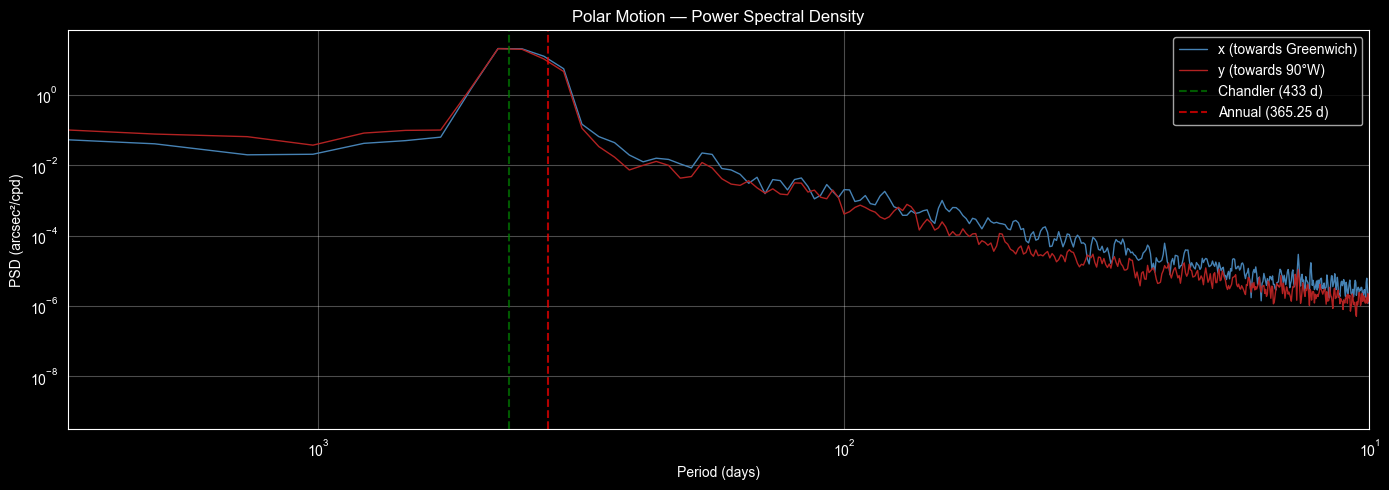

In [29]:
# Complex polar motion
pm = (eop['x'] - 1j * eop['y']).dropna()

# Remove linear trend from both components
x_det = signal.detrend(eop['x'].dropna().values)
y_det = signal.detrend(eop['y'].dropna().values)
pm_det = x_det - 1j * y_det
pm_idx = eop['x'].dropna().index

# PSD of polar motion amplitude
nperseg_pm = 4096
f_pm, psd_x = signal.welch(x_det, fs=1.0, nperseg=nperseg_pm, noverlap=nperseg_pm//2)
_, psd_y = signal.welch(y_det, fs=1.0, nperseg=nperseg_pm, noverlap=nperseg_pm//2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.loglog(1/f_pm[1:], psd_x[1:], lw=1, color='steelblue', label='x (towards Greenwich)')
ax.loglog(1/f_pm[1:], psd_y[1:], lw=1, color='firebrick', label='y (towards 90°W)')

ax.axvline(433, ls='--', color='green', alpha=0.7, label='Chandler (433 d)')
ax.axvline(365.25, ls='--', color='red', alpha=0.7, label='Annual (365.25 d)')

ax.set_xlabel('Period (days)')
ax.set_ylabel('PSD (arcsec²/cpd)')
ax.set_title('Polar Motion — Power Spectral Density')
ax.set_xlim(10, 3000)
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.show()

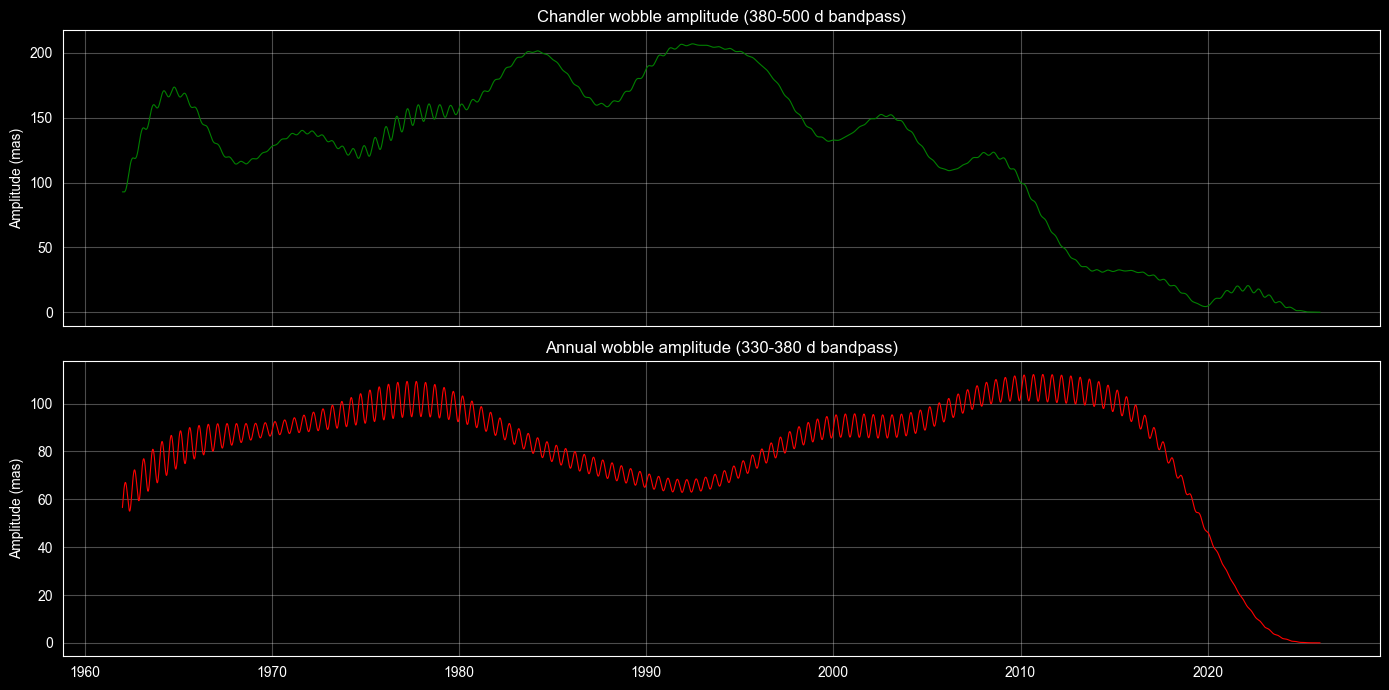

Chandler wobble — mean amplitude: 122.3 mas, std: 61.6 mas
Annual wobble — mean amplitude: 80.4 mas, std: 25.6 mas

Variance ratio (Chandler/Annual): 5.78


In [30]:
# Extract Chandler and annual wobble via bandpass
x_chandler = bandpass(x_det, 500, 380)
y_chandler = bandpass(y_det, 500, 380)
x_annual = bandpass(x_det, 380, 330)
y_annual = bandpass(y_det, 380, 330)

amp_chandler = np.sqrt(x_chandler**2 + y_chandler**2)
amp_annual = np.sqrt(x_annual**2 + y_annual**2)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(pm_idx, amp_chandler * 1000, lw=0.8, color='green')
axes[0].set_ylabel('Amplitude (mas)')
axes[0].set_title('Chandler wobble amplitude (380-500 d bandpass)')

axes[1].plot(pm_idx, amp_annual * 1000, lw=0.8, color='red')
axes[1].set_ylabel('Amplitude (mas)')
axes[1].set_title('Annual wobble amplitude (330-380 d bandpass)')

plt.tight_layout()
plt.show()

print(f"Chandler wobble — mean amplitude: {np.mean(amp_chandler)*1000:.1f} mas, std: {np.std(amp_chandler)*1000:.1f} mas")
print(f"Annual wobble — mean amplitude: {np.mean(amp_annual)*1000:.1f} mas, std: {np.std(amp_annual)*1000:.1f} mas")
print(f"\nVariance ratio (Chandler/Annual): {np.var(amp_chandler)/np.var(amp_annual):.2f}")

## 11. Wobble amplitude decline — quantifying the trend

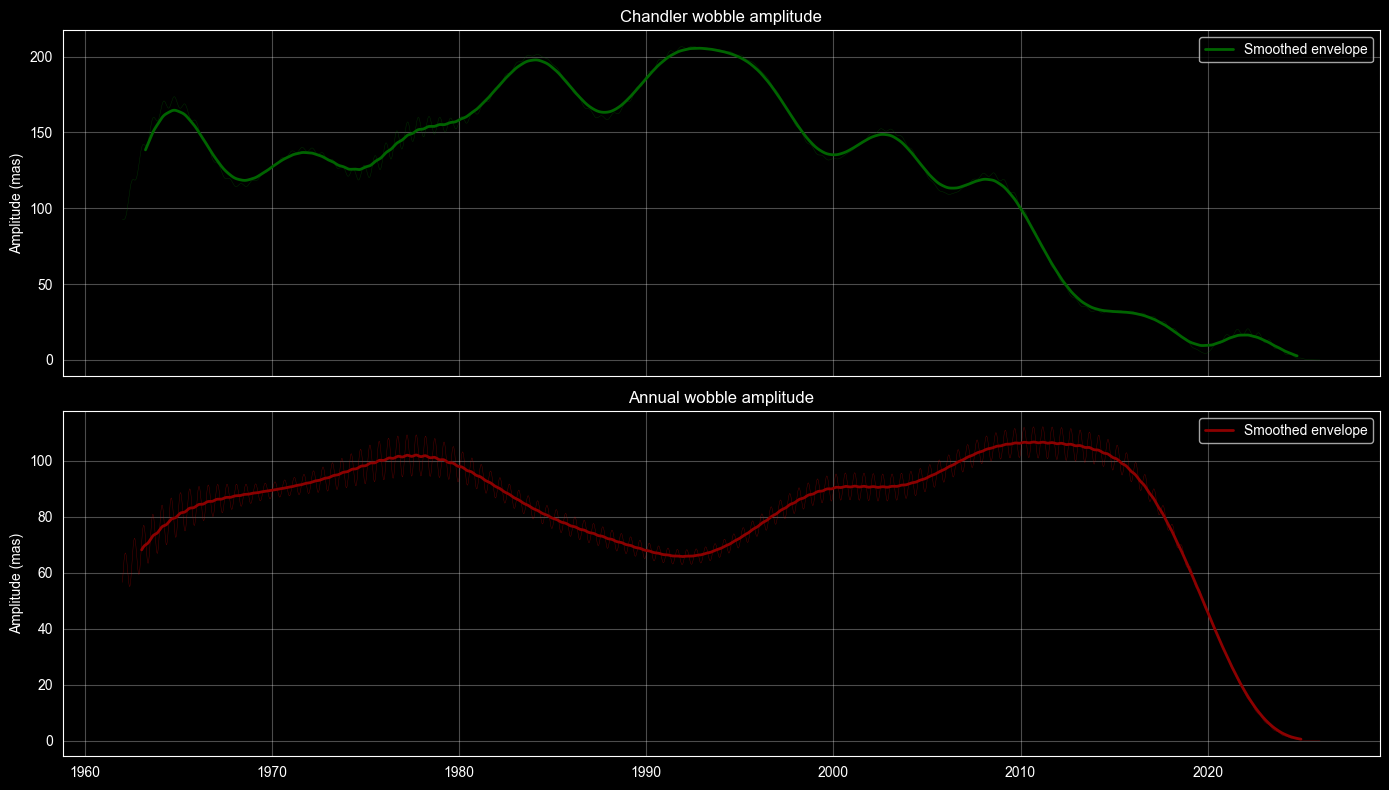

Decade           Chandler mean (mas)    Annual mean (mas)
----------------------------------------------------------
1970-1980                      139.0                 97.1
1980-1990                      177.8                 81.0
1990-2000                      184.0                 75.0
2000-2010                      128.5                 96.3
2010-2020                       38.1                 92.5
2020-2030                        9.6                 13.0


In [31]:
# Smooth the amplitude envelopes with a running mean (~2x the wobble period)
chandler_smooth = pd.Series(amp_chandler * 1000, index=pm_idx).rolling(900, center=True).mean()
annual_smooth = pd.Series(amp_annual * 1000, index=pm_idx).rolling(750, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Chandler
axes[0].plot(pm_idx, amp_chandler * 1000, lw=0.3, alpha=0.4, color='green')
axes[0].plot(chandler_smooth.index, chandler_smooth, lw=2, color='darkgreen', label='Smoothed envelope')
axes[0].set_ylabel('Amplitude (mas)')
axes[0].set_title('Chandler wobble amplitude')
axes[0].legend()

# Annual
axes[1].plot(pm_idx, amp_annual * 1000, lw=0.3, alpha=0.4, color='red')
axes[1].plot(annual_smooth.index, annual_smooth, lw=2, color='darkred', label='Smoothed envelope')
axes[1].set_ylabel('Amplitude (mas)')
axes[1].set_title('Annual wobble amplitude')
axes[1].legend()

plt.tight_layout()
plt.show()

# Decadal statistics
print(f"{'Decade':<15} {'Chandler mean (mas)':>20} {'Annual mean (mas)':>20}")
print('-' * 58)
for start in range(1970, 2030, 10):
    end = start + 10
    mask = (pm_idx >= f'{start}-01-01') & (pm_idx < f'{end}-01-01')
    if mask.sum() > 365:
        c_mean = np.mean(amp_chandler[mask]) * 1000
        a_mean = np.mean(amp_annual[mask]) * 1000
        print(f"{start}-{end:<10} {c_mean:>20.1f} {a_mean:>20.1f}")

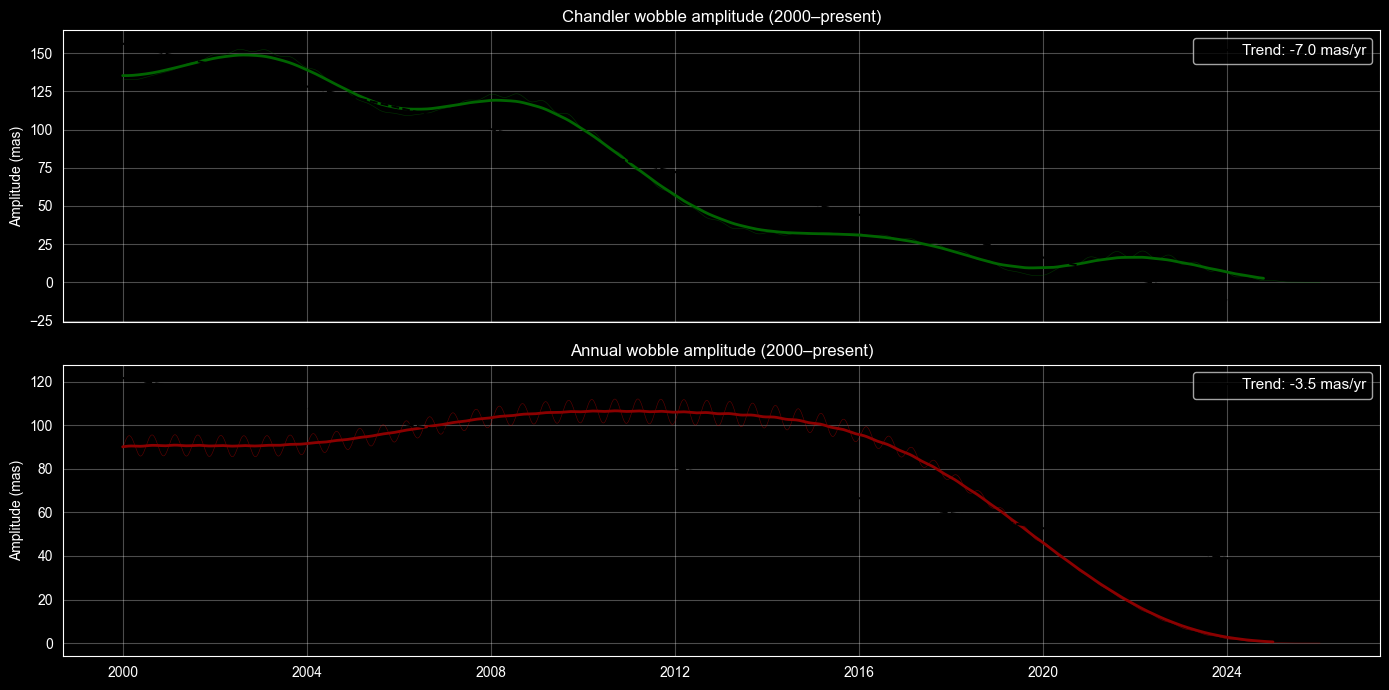

Chandler amplitude trend (2000-present): -7.00 mas/yr
Annual amplitude trend (2000-present):   -3.45 mas/yr

Chandler amplitude — 2000 vs now: 156.2 → -17.2 mas
Annual amplitude — 2000 vs now:   121.8 → 35.5 mas


In [32]:
# Zoom in on recent 25 years + linear trend fit
from numpy.polynomial import polynomial as P

recent_mask = pm_idx >= '2000-01-01'
t_recent = (pm_idx[recent_mask] - pm_idx[recent_mask][0]).days.values.astype(float)

# Fit linear trends to smoothed envelopes
c_recent = chandler_smooth[recent_mask].dropna()
a_recent = annual_smooth[recent_mask].dropna()
t_c = (c_recent.index - c_recent.index[0]).days.values.astype(float)
t_a = (a_recent.index - a_recent.index[0]).days.values.astype(float)

coef_c = P.polyfit(t_c, c_recent.values, 1)
coef_a = P.polyfit(t_a, a_recent.values, 1)

# Slopes in mas/year
slope_c = coef_c[1] * 365.25
slope_a = coef_a[1] * 365.25

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(pm_idx[recent_mask], amp_chandler[recent_mask] * 1000, lw=0.4, alpha=0.4, color='green')
axes[0].plot(c_recent.index, c_recent, lw=2, color='darkgreen')
axes[0].plot(c_recent.index, P.polyval(t_c, coef_c), lw=1.5, ls='--', color='black',
             label=f'Trend: {slope_c:.1f} mas/yr')
axes[0].set_ylabel('Amplitude (mas)')
axes[0].set_title('Chandler wobble amplitude (2000–present)')
axes[0].legend(fontsize=11)

axes[1].plot(pm_idx[recent_mask], amp_annual[recent_mask] * 1000, lw=0.4, alpha=0.4, color='red')
axes[1].plot(a_recent.index, a_recent, lw=2, color='darkred')
axes[1].plot(a_recent.index, P.polyval(t_a, coef_a), lw=1.5, ls='--', color='black',
             label=f'Trend: {slope_a:.1f} mas/yr')
axes[1].set_ylabel('Amplitude (mas)')
axes[1].set_title('Annual wobble amplitude (2000–present)')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"Chandler amplitude trend (2000-present): {slope_c:.2f} mas/yr")
print(f"Annual amplitude trend (2000-present):   {slope_a:.2f} mas/yr")
print(f"\nChandler amplitude — 2000 vs now: {P.polyval(t_c[0], coef_c):.1f} → {P.polyval(t_c[-1], coef_c):.1f} mas")
print(f"Annual amplitude — 2000 vs now:   {P.polyval(t_a[0], coef_a):.1f} → {P.polyval(t_a[-1], coef_a):.1f} mas")

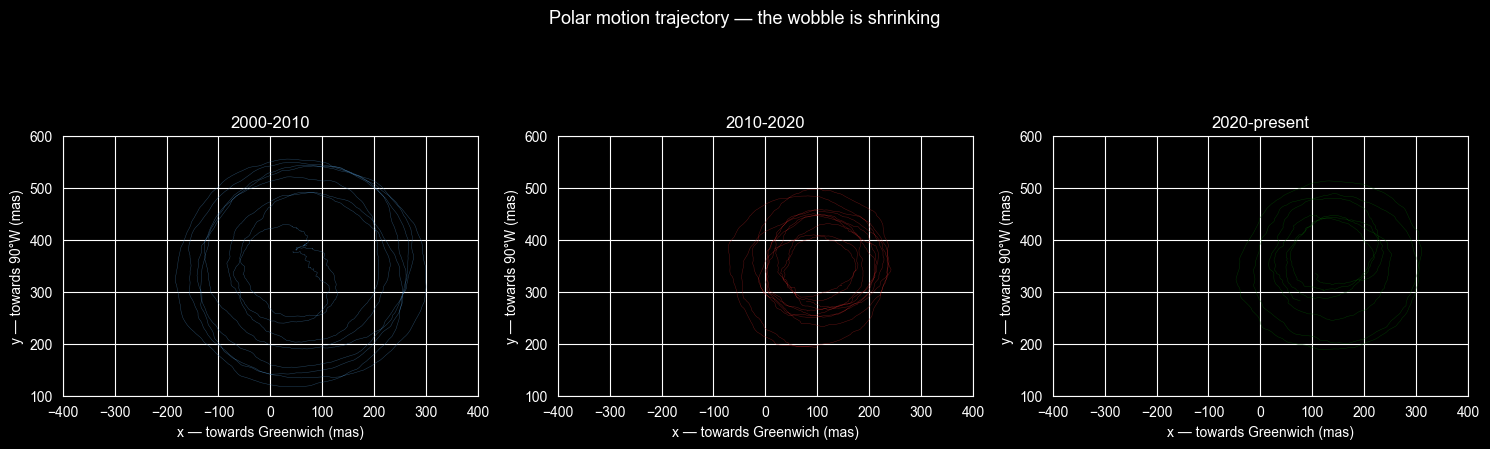

In [35]:
# Polar motion trajectory: x vs y for recent decades
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

decades = [('2000-2010', '2000-01-01', '2010-01-01', 'steelblue'),
           ('2010-2020', '2010-01-01', '2020-01-01', 'firebrick'),
           ('2020-present', '2020-01-01', '2027-01-01', 'darkgreen')]

for ax, (label, t0, t1, color) in zip(axes, decades):
    mask = (pm_idx >= t0) & (pm_idx < t1)
    ax.plot(eop.loc[pm_idx[mask], 'x'] * 1000,
            eop.loc[pm_idx[mask], 'y'] * 1000,
            lw=0.3, color=color, alpha=0.6)
    ax.set_xlabel('x — towards Greenwich (mas)')
    ax.set_ylabel('y — towards 90°W (mas)')
    ax.set_title(label)
    ax.set_aspect('equal')
    ax.set_xlim(-400, 400)
    ax.set_ylim(100, 600)

fig.suptitle('Polar motion trajectory — the wobble is shrinking', fontsize=13)
plt.tight_layout()
plt.show()